In [3]:
#1 Imports

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score

from PIL import Image

In [4]:
#2 Device and Seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Using device:", device)

Using device: cpu


In [5]:
#3 Basic transform and CIFAR10 Dataset Preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Download CIFAR-10 train and test WITHOUT transform
cifar_train_raw = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=None
)

cifar_test_raw = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=None
)

# Combine 50,000 train images + 10,000 test images = 60,000 total images
all_data = np.concatenate(
    [cifar_train_raw.data, cifar_test_raw.data],
    axis=0
)

all_targets = np.array(
    cifar_train_raw.targets + cifar_test_raw.targets
)

# Custom dataset for the full 60,000 images
class FullCIFAR10(Dataset):
    def __init__(self, data, targets, transform=None):
        self.data = data
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        image = Image.fromarray(self.data[idx])
        label = self.targets[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Full dataset with transforms
full_dataset = FullCIFAR10(
    all_data,
    all_targets,
    transform=transform
)

# Batch size
batch_size = 128

print("Total images:", len(full_dataset))

Total images: 60000


In [6]:
#4 Model Class

class HybridTwoStreamNetwork(nn.Module):
    def __init__(self):
        super(HybridTwoStreamNetwork, self).__init__()
        
        # BRANCH A: CNN feature extractor
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.cnn_output_size = 64 * 8 * 8
        
        # BRANCH B: MLP branch
        self.mlp_input_size = 3 * 8 * 8
        
        self.mlp_fc1 = nn.Linear(self.mlp_input_size, 128)
        self.mlp_fc2 = nn.Linear(128, 64)
        
        # Fusion classifier
        self.fusion_size = self.cnn_output_size + 64
        self.classifier = nn.Linear(self.fusion_size, 10)

    def forward(self, x):
        # CNN branch
        cnn_out = self.conv1(x)
        cnn_out = self.bn1(cnn_out)
        cnn_out = F.relu(cnn_out)
        cnn_out = F.max_pool2d(cnn_out, 2)
        
        cnn_out = self.conv2(cnn_out)
        cnn_out = self.bn2(cnn_out)
        cnn_out = F.relu(cnn_out)
        cnn_out = F.max_pool2d(cnn_out, 2)
        
        cnn_out = cnn_out.view(cnn_out.size(0), -1)
        
        # MLP branch
        mlp_out = F.avg_pool2d(x, 4)
        mlp_out = mlp_out.view(mlp_out.size(0), -1)
        
        mlp_out = F.relu(self.mlp_fc1(mlp_out))
        mlp_out = F.relu(self.mlp_fc2(mlp_out))
        
        # Combine branches
        combined_features = torch.cat((cnn_out, mlp_out), dim=1)
        
        output = self.classifier(combined_features)
        
        return output

In [7]:
#5 Training Loop with Gradient Norm Tracking
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1, gradient_norms

In [8]:
#6 Test

def test(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1

In [10]:
def average_state_dicts(state_dicts):
    averaged_state = {}

    for key in state_dicts[0].keys():
        tensors = [state_dict[key] for state_dict in state_dicts]

        if tensors[0].is_floating_point():
            averaged_state[key] = torch.stack(tensors, dim=0).mean(dim=0)
        else:
            averaged_state[key] = tensors[0]

    return averaged_state


num_epochs = 15
batch_size = 128

criterion = nn.CrossEntropyLoss()

model = HybridTwoStreamNetwork().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

targets = all_targets

train_losses = []
test_losses = []

train_accs = []
test_accs = []

train_f1s = []
test_f1s = []

all_epoch_gradient_norms = []
saved_states_for_averaging = []

for epoch in range(num_epochs):

    splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=50000,
        test_size=10000,
        random_state=seed + epoch
    )

    train_idx, test_idx = next(
        splitter.split(np.zeros(len(targets)), targets)
    )

    epoch_train_dataset = Subset(full_dataset, train_idx)
    epoch_test_dataset = Subset(full_dataset, test_idx)

    epoch_train_loader = DataLoader(
        epoch_train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    epoch_test_loader = DataLoader(
        epoch_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Train normally
    train_loss, train_acc, train_f1, grad_norms = train_one_epoch(
        model,
        epoch_train_loader,
        optimizer,
        criterion,
        device
    )

    # Save weights from epochs 11, 12, 13, 14, and 15
    if 11 <= epoch + 1 <= 15:
        saved_states_for_averaging.append(
            {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        )

    # After epoch 15 training, average epochs 11-15 and load averaged weights
    if epoch + 1 == 15:
        averaged_state = average_state_dicts(saved_states_for_averaging)
        model.load_state_dict(averaged_state)

    # Test
    test_loss, test_acc, test_f1 = test(
        model,
        epoch_test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)

    epoch_grad_averages = {}

    for layer_name, batch_norms in grad_norms.items():
        epoch_grad_averages[layer_name] = sum(batch_norms) / len(batch_norms)

    all_epoch_gradient_norms.append(epoch_grad_averages)

    print(f"Epoch {epoch + 1}/{num_epochs}")

    if epoch + 1 == 15:
        print("Using averaged weights from epochs 11, 12, 13, 14, and 15")

    print(f"Training images this epoch: 50,000")
    print(f"Test images this epoch: 10,000")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}% | Test Accuracy: {test_acc:.2f}%")
    print(f"Train Macro-F1: {train_f1:.4f} | Test Macro-F1: {test_f1:.4f}")

    print("Average Gradient Magnitudes:")
    for layer, magnitude in epoch_grad_averages.items():
        print(f"  {layer}: {magnitude:.6f}")

    print("-" * 40)

Epoch 1/15
Training images this epoch: 50,000
Test images this epoch: 10,000
Train Loss: 1.3221 | Test Loss: 1.0592
Train Accuracy: 53.65% | Test Accuracy: 62.36%
Train Macro-F1: 0.5349 | Test Macro-F1: 0.6212
Average Gradient Magnitudes:
  conv1.weight: 2.058858
  conv1.bias: 0.000010
  bn1.weight: 0.084555
  bn1.bias: 0.053289
  conv2.weight: 1.191299
  conv2.bias: 0.000000
  bn2.weight: 0.131910
  bn2.bias: 0.133666
  mlp_fc1.weight: 0.046994
  mlp_fc1.bias: 0.008611
  mlp_fc2.weight: 0.053348
  mlp_fc2.bias: 0.011924
  classifier.weight: 5.490152
  classifier.bias: 0.117685
----------------------------------------
Epoch 2/15
Training images this epoch: 50,000
Test images this epoch: 10,000
Train Loss: 0.9707 | Test Loss: 0.9638
Train Accuracy: 66.35% | Test Accuracy: 66.88%
Train Macro-F1: 0.6626 | Test Macro-F1: 0.6586
Average Gradient Magnitudes:
  conv1.weight: 3.280593
  conv1.bias: 0.000022
  bn1.weight: 0.111250
  bn1.bias: 0.070524
  conv2.weight: 1.184651
  conv2.bias: 0.00

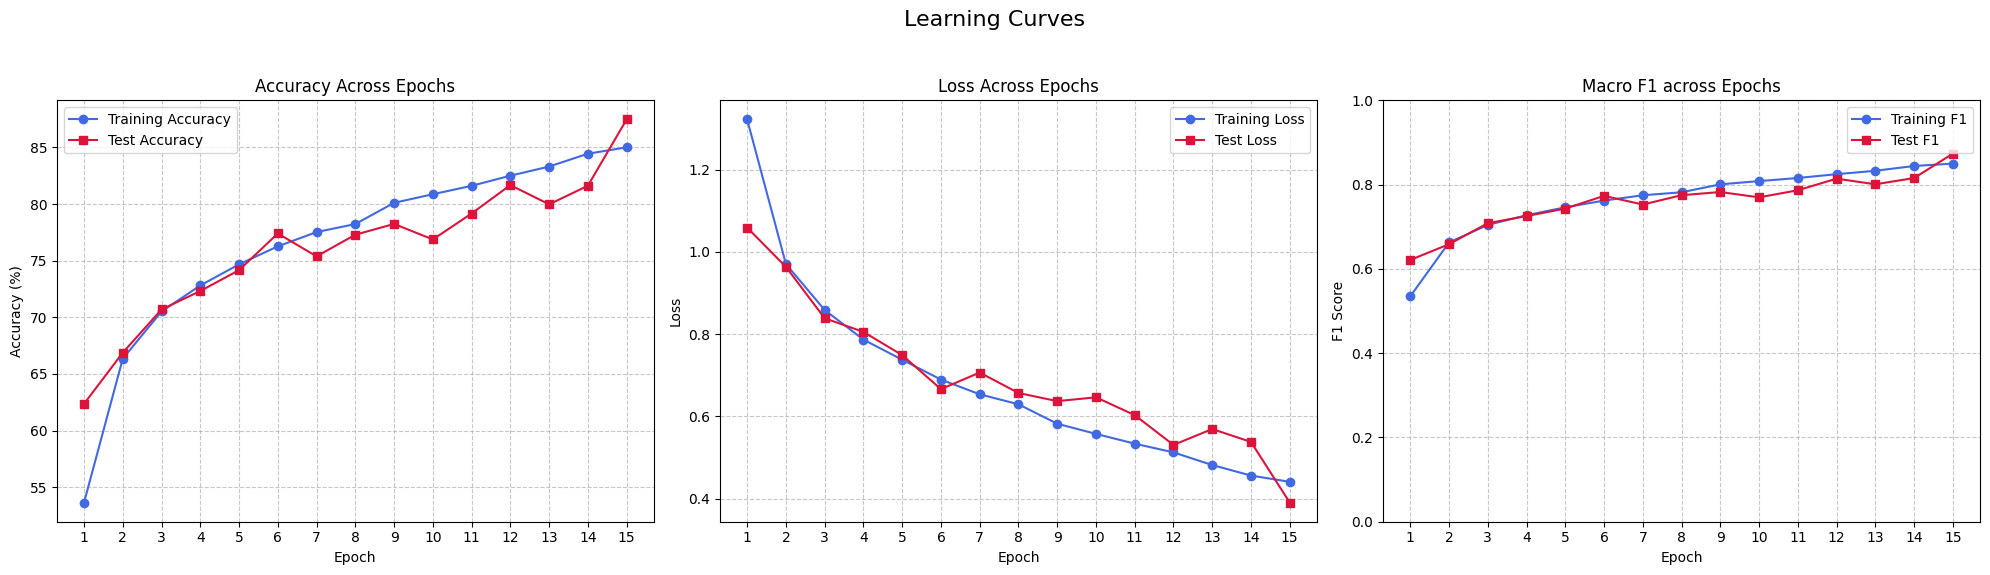

In [12]:
import matplotlib.pyplot as plt

# Define the epoch range (1 to num_epochs)
epochs = range(1, num_epochs + 1)

# Create the main figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Learning Curves', fontsize=16)

# --- Plot 1: Accuracy ---
ax1.plot(epochs, train_accs, marker='o', label='Training Accuracy', color='royalblue')
ax1.plot(epochs, test_accs, marker='s', label='Test Accuracy', color='crimson')
ax1.set_title('Accuracy Across Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(epochs) # Ensure axis shows every epoch from 1 to num_epochs
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Loss ---
ax2.plot(epochs, train_losses, marker='o', label='Training Loss', color='royalblue')
ax2.plot(epochs, test_losses, marker='s', label='Test Loss', color='crimson')
ax2.set_title('Loss Across Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_xticks(epochs) # Ensure axis shows every epoch from 1 to num_epochs
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# --- Plot 3: F1 Score ---
ax3.plot(epochs, train_f1s, marker='o', label='Training F1', color='royalblue')
ax3.plot(epochs, test_f1s, marker='s', label='Test F1', color='crimson')
ax3.set_title('Macro F1 across Epochs')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Score')
ax3.set_xticks(epochs)
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

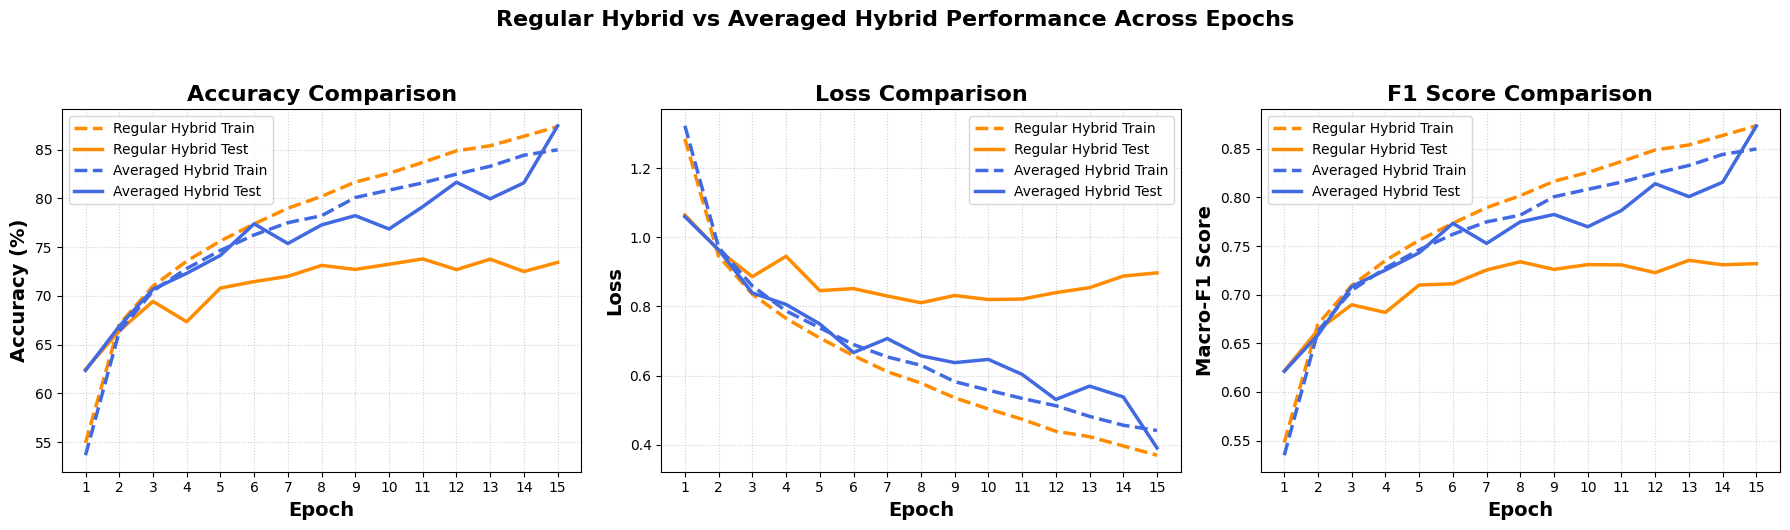

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = range(1, 16)

# ----------------------------------------------------
# Data 1: Regular Hybrid Model
# ----------------------------------------------------
train_loss_hybrid = [1.2843, 0.9452, 0.8353, 0.7652, 0.7086, 0.6576, 0.6112, 0.5781, 0.5356, 0.5032, 0.4737, 0.4389, 0.4232, 0.3964, 0.3695]
test_loss_hybrid  = [1.0641, 0.9621, 0.8859, 0.9448, 0.8456, 0.8513, 0.8300, 0.8105, 0.8314, 0.8198, 0.8211, 0.8397, 0.8541, 0.8876, 0.8969]

train_acc_hybrid = [54.93, 67.08, 71.01, 73.57, 75.64, 77.39, 79.00, 80.22, 81.69, 82.58, 83.71, 84.89, 85.41, 86.39, 87.37]
test_acc_hybrid  = [62.47, 66.41, 69.44, 67.35, 70.81, 71.47, 72.01, 73.13, 72.72, 73.25, 73.80, 72.70, 73.77, 72.51, 73.44]

train_f1_hybrid = [0.5480, 0.6698, 0.7094, 0.7351, 0.7560, 0.7734, 0.7895, 0.8018, 0.8166, 0.8256, 0.8369, 0.8488, 0.8539, 0.8637, 0.8736]
test_f1_hybrid  = [0.6216, 0.6637, 0.6896, 0.6817, 0.7099, 0.7112, 0.7254, 0.7338, 0.7260, 0.7309, 0.7306, 0.7226, 0.7353, 0.7307, 0.7319]


# ----------------------------------------------------
# Data 2: Hybrid Model with Weight Averaging
# ----------------------------------------------------
train_loss_hybrid_avg = [1.3221, 0.9707, 0.8588, 0.7869, 0.7379, 0.6897, 0.6539, 0.6296, 0.5824, 0.5576, 0.5339, 0.5127, 0.4819, 0.4563, 0.4411]
test_loss_hybrid_avg  = [1.0592, 0.9638, 0.8388, 0.8056, 0.7491, 0.6665, 0.7068, 0.6571, 0.6373, 0.6466, 0.6033, 0.5308, 0.5694, 0.5381, 0.3906]

train_acc_hybrid_avg = [53.65, 66.35, 70.51, 72.81, 74.67, 76.26, 77.52, 78.23, 80.10, 80.86, 81.60, 82.50, 83.31, 84.44, 85.00]
test_acc_hybrid_avg  = [62.36, 66.88, 70.69, 72.32, 74.16, 77.40, 75.38, 77.29, 78.24, 76.87, 79.16, 81.67, 79.97, 81.61, 87.46]

train_f1_hybrid_avg = [0.5349, 0.6626, 0.7043, 0.7274, 0.7461, 0.7621, 0.7748, 0.7818, 0.8007, 0.8083, 0.8157, 0.8248, 0.8328, 0.8442, 0.8498]
test_f1_hybrid_avg  = [0.6212, 0.6586, 0.7084, 0.7253, 0.7431, 0.7733, 0.7527, 0.7749, 0.7824, 0.7698, 0.7866, 0.8141, 0.8008, 0.8156, 0.8735]


# ----------------------------------------------------
# Visual settings
# ----------------------------------------------------
plt.figure(figsize=(18, 5))

regular_color = "darkorange"
avg_color = "royalblue"

train_style = "--"
test_style = "-"

line_width = 2.5
marker_size = 5


# ----------------------------------------------------
# Plot 1: Accuracy Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 1)

plt.plot(epochs, train_acc_hybrid, label="Regular Hybrid Train", color=regular_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_acc_hybrid, label="Regular Hybrid Test", color=regular_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_acc_hybrid_avg, label="Averaged Hybrid Train", color=avg_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_acc_hybrid_avg, label="Averaged Hybrid Test", color=avg_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("Accuracy Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()


# ----------------------------------------------------
# Plot 2: Loss Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 2)

plt.plot(epochs, train_loss_hybrid, label="Regular Hybrid Train", color=regular_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_loss_hybrid, label="Regular Hybrid Test", color=regular_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_loss_hybrid_avg, label="Averaged Hybrid Train", color=avg_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_loss_hybrid_avg, label="Averaged Hybrid Test", color=avg_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("Loss Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("Loss", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()


# ----------------------------------------------------
# Plot 3: F1 Score Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 3)

plt.plot(epochs, train_f1_hybrid, label="Regular Hybrid Train", color=regular_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_f1_hybrid, label="Regular Hybrid Test", color=regular_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_f1_hybrid_avg, label="Averaged Hybrid Train", color=avg_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_f1_hybrid_avg, label="Averaged Hybrid Test", color=avg_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("F1 Score Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("F1 Score", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()


# ----------------------------------------------------
# Final formatting
# ----------------------------------------------------
plt.suptitle("Regular Hybrid vs Averaged Hybrid Performance Across Epochs",
             fontsize=16, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()

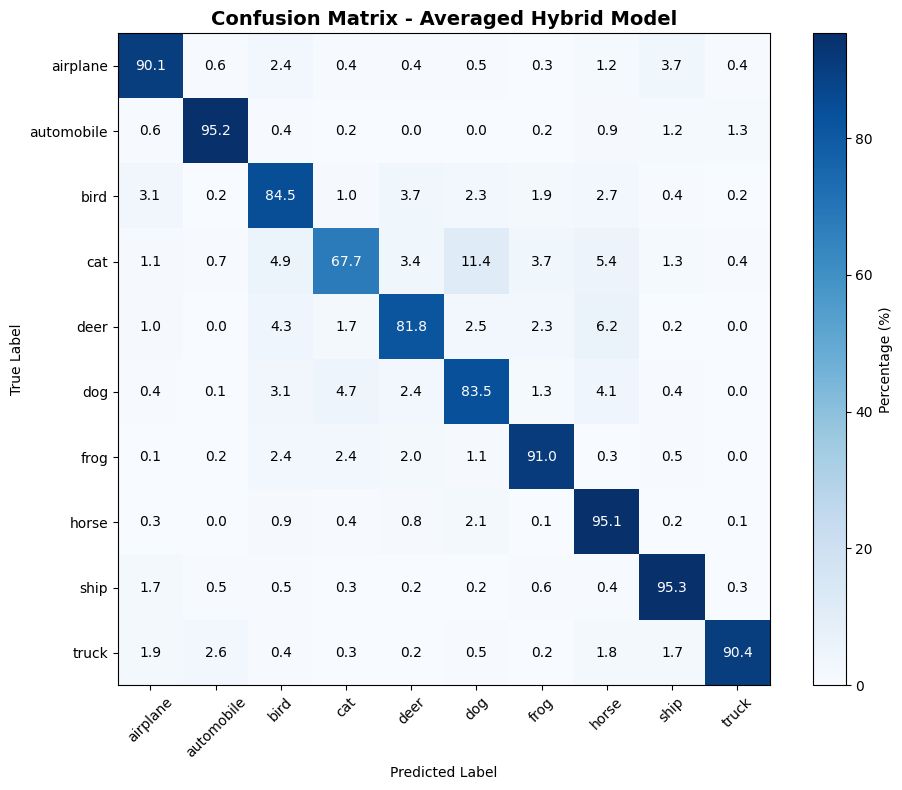

In [16]:
# ----------------------------------------------------
# Confusion Matrix - Averaged Hybrid Model
# ----------------------------------------------------
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

classes = cifar_train_raw.classes

def plot_confusion_matrix_averaged_hybrid(model, loader, classes):
    
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    # Convert to percentage by row
    cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_percent, interpolation="nearest", cmap="Blues")
    plt.title("Confusion Matrix - Averaged Hybrid Model", fontsize=14, fontweight="bold")
    plt.colorbar(label="Percentage (%)")

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add values inside cells
    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            plt.text(
                j, i,
                f"{cm_percent[i, j]:.1f}",
                ha="center",
                va="center",
                color="white" if cm_percent[i, j] > 50 else "black"
            )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


# Run confusion matrix on the averaged hybrid model
plot_confusion_matrix_averaged_hybrid(
    model=model,
    loader=epoch_test_loader,
    classes=classes
)

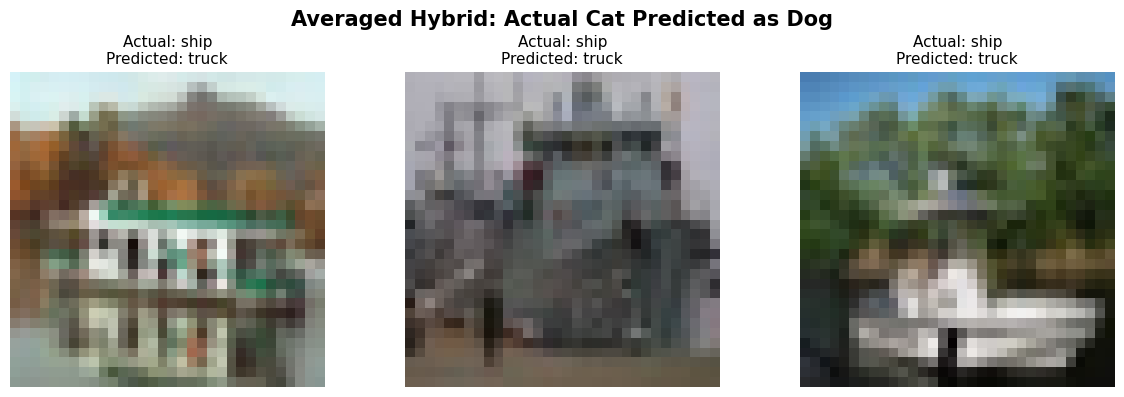

In [18]:
# ----------------------------------------------------
# Show examples: Actual Cat predicted as Dog
# Averaged Hybrid Model
# ----------------------------------------------------

def show_actual_cat_predicted_dog(model, loader, classes, max_images=8):
    
    model.eval()

    actual_class = "ship"
    predicted_class = "truck"

    actual_idx = classes.index(actual_class)
    predicted_idx = classes.index(predicted_class)

    selected_images = []
    selected_true_labels = []
    selected_pred_labels = []

    with torch.no_grad():
        for images, labels in loader:
            
            images_device = images.to(device)
            labels_device = labels.to(device)

            outputs = model(images_device)
            _, predicted = outputs.max(1)

            predicted_cpu = predicted.cpu()
            labels_cpu = labels.cpu()

            mask = (labels_cpu == actual_idx) & (predicted_cpu == predicted_idx)

            if mask.any():
                for img, true_label, pred_label in zip(
                    images[mask],
                    labels_cpu[mask],
                    predicted_cpu[mask]
                ):
                    selected_images.append(img)
                    selected_true_labels.append(true_label.item())
                    selected_pred_labels.append(pred_label.item())

                    if len(selected_images) >= max_images:
                        break

            if len(selected_images) >= max_images:
                break

    if len(selected_images) == 0:
        print("No examples found where actual cat was predicted as dog.")
        return

    n = len(selected_images)
    cols = min(4, n)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, img in enumerate(selected_images):
        
        # Undo CIFAR-10 normalization: Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
        img = img * 0.5 + 0.5
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(
            f"Actual: {classes[selected_true_labels[i]]}\nPredicted: {classes[selected_pred_labels[i]]}",
            fontsize=11
        )
        ax.axis("off")

    plt.suptitle("Averaged Hybrid: Actual Cat Predicted as Dog", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Run cat → dog example visualization
show_actual_cat_predicted_dog(
    model=model,
    loader=epoch_test_loader,
    classes=classes,
    max_images=8
)

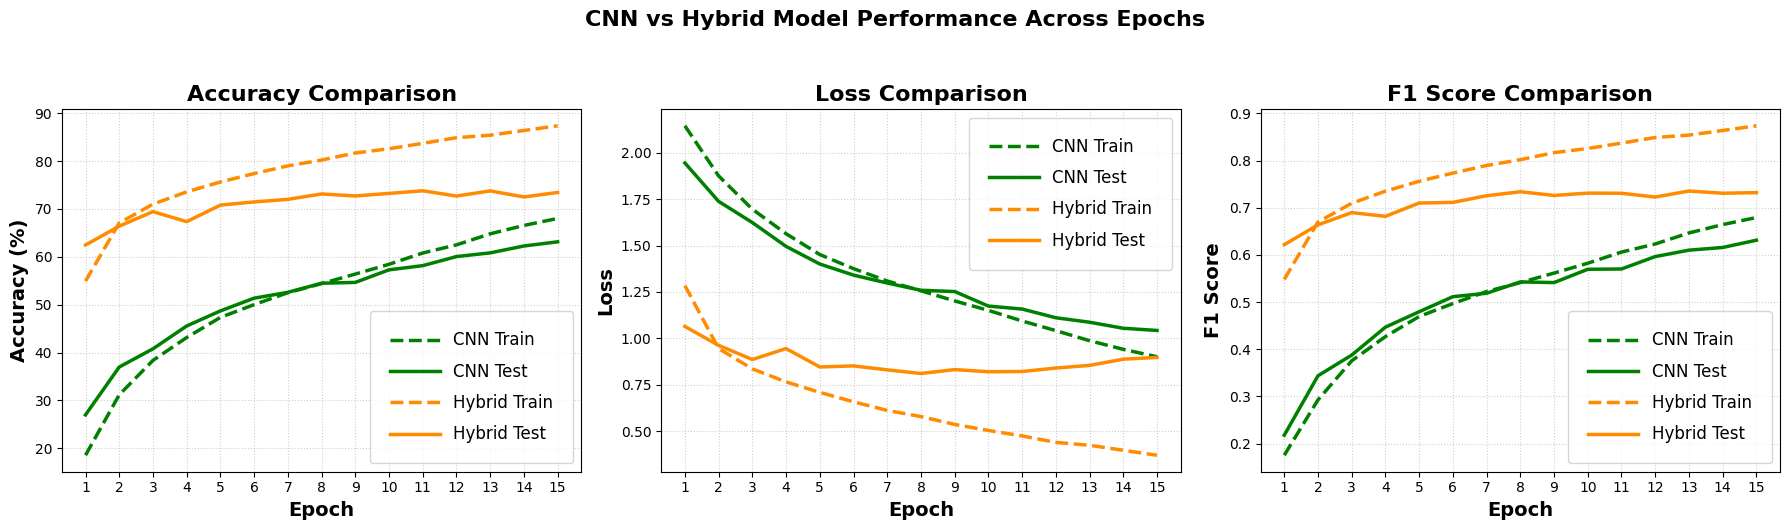

In [8]:
import matplotlib.pyplot as plt

# Epochs
epochs = range(1, 16)

# ----------------------------------------------------
# Data from Dataset 1: CNN debugged
# ----------------------------------------------------
train_loss_cnn = [2.1461, 1.8759, 1.6964, 1.5641, 1.4518, 1.3760, 1.3092, 1.2564, 1.2017, 1.1507, 1.0936, 1.0415, 0.9872, 0.9407, 0.9006]
test_loss_cnn  = [1.9457, 1.7386, 1.6244, 1.4958, 1.4008, 1.3410, 1.2982, 1.2592, 1.2523, 1.1740, 1.1579, 1.1109, 1.0869, 1.0543, 1.0425]

train_acc_cnn = [18.56, 31.19, 38.37, 43.15, 47.35, 50.02, 52.51, 54.41, 56.40, 58.45, 60.80, 62.50, 64.81, 66.56, 68.02]
test_acc_cnn  = [27.00, 36.99, 40.79, 45.56, 48.71, 51.37, 52.59, 54.49, 54.66, 57.29, 58.16, 60.06, 60.83, 62.27, 63.14]

train_f1_cnn = [0.1753, 0.2927, 0.3755, 0.4268, 0.4694, 0.4968, 0.5223, 0.5413, 0.5614, 0.5823, 0.6060, 0.6231, 0.6465, 0.6642, 0.6792]
test_f1_cnn  = [0.2178, 0.3438, 0.3876, 0.4468, 0.4795, 0.5114, 0.5187, 0.5427, 0.5413, 0.5695, 0.5701, 0.5964, 0.6100, 0.6157, 0.6311]


# ----------------------------------------------------
# Data from Dataset 2: Hybrid Model
# ----------------------------------------------------
train_loss_hybrid = [1.2843, 0.9452, 0.8353, 0.7652, 0.7086, 0.6576, 0.6112, 0.5781, 0.5356, 0.5032, 0.4737, 0.4389, 0.4232, 0.3964, 0.3695]
test_loss_hybrid  = [1.0641, 0.9621, 0.8859, 0.9448, 0.8456, 0.8513, 0.8300, 0.8105, 0.8314, 0.8198, 0.8211, 0.8397, 0.8541, 0.8876, 0.8969]

train_acc_hybrid = [54.93, 67.08, 71.01, 73.57, 75.64, 77.39, 79.00, 80.22, 81.69, 82.58, 83.71, 84.89, 85.41, 86.39, 87.37]
test_acc_hybrid  = [62.47, 66.41, 69.44, 67.35, 70.81, 71.47, 72.01, 73.13, 72.72, 73.25, 73.80, 72.70, 73.77, 72.51, 73.44]

train_f1_hybrid = [0.5480, 0.6698, 0.7094, 0.7351, 0.7560, 0.7734, 0.7895, 0.8018, 0.8166, 0.8256, 0.8369, 0.8488, 0.8539, 0.8637, 0.8736]
test_f1_hybrid  = [0.6216, 0.6637, 0.6896, 0.6817, 0.7099, 0.7112, 0.7254, 0.7338, 0.7260, 0.7309, 0.7306, 0.7226, 0.7353, 0.7307, 0.7319]


# ----------------------------------------------------
# General visual settings
# ----------------------------------------------------
plt.figure(figsize=(18, 5))

cnn_color = "green"
hybrid_color = "darkorange"

train_style = "--"
test_style = "-"

line_width = 2.5
marker_size = 5


# ----------------------------------------------------
# Plot 1: Accuracy Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 1)

plt.plot(epochs, train_acc_cnn, label="CNN Train", color=cnn_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_acc_cnn, label="CNN Test", color=cnn_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_acc_hybrid, label="Hybrid Train", color=hybrid_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_acc_hybrid, label="Hybrid Test", color=hybrid_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("Accuracy Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(
    fontsize=12,        # bigger text
    markerscale=1.5,    # bigger markers in legend
    handlelength=3,     # longer line samples
    borderpad=1.2,      # more space inside legend box
    labelspacing=0.8,   # more space between rows
    frameon=True
)


# ----------------------------------------------------
# Plot 2: Loss Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 2)

plt.plot(epochs, train_loss_cnn, label="CNN Train", color=cnn_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_loss_cnn, label="CNN Test", color=cnn_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_loss_hybrid, label="Hybrid Train", color=hybrid_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_loss_hybrid, label="Hybrid Test", color=hybrid_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("Loss Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("Loss", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(
    fontsize=12,        # bigger text
    markerscale=1.5,    # bigger markers in legend
    handlelength=3,     # longer line samples
    borderpad=1.2,      # more space inside legend box
    labelspacing=0.8,   # more space between rows
    frameon=True
)


# ----------------------------------------------------
# Plot 3: F1 Score Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 3)

plt.plot(epochs, train_f1_cnn, label="CNN Train", color=cnn_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_f1_cnn, label="CNN Test", color=cnn_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_f1_hybrid, label="Hybrid Train", color=hybrid_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_f1_hybrid, label="Hybrid Test", color=hybrid_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("F1 Score Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("F1 Score", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(
    fontsize=12,        # bigger text
    markerscale=1.5,    # bigger markers in legend
    handlelength=3,     # longer line samples
    borderpad=1.2,      # more space inside legend box
    labelspacing=0.8,   # more space between rows
    frameon=True
)


# ----------------------------------------------------
# Final formatting
# ----------------------------------------------------
plt.suptitle("CNN vs Hybrid Model Performance Across Epochs", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()